# Accumulated Local Effects (ALE) - Course

This course provides an in-depth understanding of Accumulated Local Effects (ALE), a powerful technique for interpreting machine learning models (especially black-box models). ALE helps to visualize the effect of individual features on the model's predictions while accounting for feature interactions.

## 1. Setup and Dataset Generation

We will start by generating a small synthetic dataset of 50 samples. This small size will allow us to easily understand the "local" nature of the calculations.

We'll generate two features:
*   `Feature_A`: Has a linear relationship with the target.
*   `Feature_B`: Has a non-linear (quadratic) relationship with the target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Set seed for reproducibility
np.random.seed(42)

# Generate 50 samples
n_samples = 50
X = pd.DataFrame({
    'Feature_A': np.linspace(0, 10, n_samples),
    'Feature_B': np.random.normal(5, 2, n_samples)
})

# Create a target variable with some relationship
# y = 2*A + (B-5)^2 + "noise"
y = 2 * X['Feature_A'] + (X['Feature_B'] - 5)**2 + np.random.normal(0, 0.5, n_samples)

print("Dataset Head:")
print(X.head())

Dataset Head:
   Feature_A  Feature_B
0   0.000000   5.993428
1   0.204082   4.723471
2   0.408163   6.295377
3   0.612245   8.046060
4   0.816327   4.531693


## 2. Model Training

We train a `RandomForestRegressor` on this data. The choice of model is arbitrary; ALE works for any "black box" model that outputs a prediction.

Note: Here, we do not perform hyperparameter tuning or cross-validation for simplicity. This is not problematic for our purpose, which is to illustrate the ALE technique rather than to achieve optimal predictive performance.

In [2]:
model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
model.fit(X, y)
print("Model trained.")

Model trained.


## 3. Manual ALE Implementation

Here we implement the ALE algorithm from scratch.

### The Logic:
1.  **Binning**: We divide the feature of interest into intervals (bins), typically using quantiles so each bin has roughly the same number of samples.
2.  **Local Effects**: For each interval, we look at the data points that fall inside it. For these points, we calculate the difference in the model's prediction if we were to change the feature value from the left edge of the interval ($z_{k-1}$) to the right edge ($z_k$).
    *   $Effect_{local} = Prediction(feature=z_k) - Prediction(feature=z_{k-1})$
    *   This isolates the effect of the feature *within* that small range, keeping all other features constant.
3.  **Aggregation**: We average these local effects for each bin.
4.  **Accumulation**: We calculate the cumulative sum of these average effects to get the "Accumulated" profile.
5.  **Centering**: To make the interpretation easier (showing deviation from the mean prediction), we center the ALE curve so that its average value is zero.


### Why it makes sense to proceed this way:

The local effect formula captures the change in prediction when the feature of interest moves from one bin edge to another, while keeping all other features constant. This isolates the effect of the feature within that small range, allowing us to understand how changes in that feature influence the model's output.

Think of it as building a staircase: each step (local effect) shows how much the prediction changes as we move up the stairs (feature values), and by summing these steps, we get the overall height (accumulated effect) relative to the average height (centering).

By increasingly accumulating these local effects across the bins, we build up a picture of how the feature affects predictions over its entire range. Centering the ALE curve ensures that we are looking at deviations from the average prediction, making it easier to interpret the results.

In this notebook, the number of bins is small (10), for two reasons:
1.   To keep the calculations and visualizations simple and understandable.
2.   Because we have a small dataset (50 samples), using too many bins would lead to very few samples per bin, making the local effect estimates noisy and unreliable.
But imagine having a much larger dataset (thousands of samples). In that case, we could use more bins (e.g., 20, 50, or even 100) to capture more detailed variations in the feature's effect on the model's predictions. Think of it the way you learnt to compute an integral: with more bins, you get a finer approximation of the area under the curve, leading to a more accurate estimation.

In [3]:
def calculate_ale(model, X, feature, n_bins=10):
    # 1. Divide feature into intervals (using quantiles to ensure data in bins)
    quantiles = np.linspace(0, 1, n_bins + 1)
    grid = np.unique(np.quantile(X[feature], quantiles))
    
    ale_values = [0] # Initialize with 0
    bin_counts = []
    
    # 2. Iterate through intervals
    for i in range(len(grid) - 1):
        z_lower = grid[i]
        z_upper = grid[i+1]
        
        # Find samples in this bin (z_lower <= x < z_upper)
        if i == len(grid) - 2:
            indices = X[(X[feature] >= z_lower) & (X[feature] <= z_upper)].index
        else:
            indices = X[(X[feature] >= z_lower) & (X[feature] < z_upper)].index
            
        if len(indices) == 0:
            ale_values.append(ale_values[-1]) # No change if empty
            bin_counts.append(0)
            continue
            
        # Get the subset of data
        X_subset = X.loc[indices].copy()
        
        # 3. Create modified datasets
        # Replace feature column with z_lower
        X_lower = X_subset.copy()
        X_lower[feature] = z_lower
        
        # Replace feature column with z_upper
        X_upper = X_subset.copy()
        X_upper[feature] = z_upper
        
        # Predict
        preds_lower = model.predict(X_lower)
        preds_upper = model.predict(X_upper)
        
        # Calculate local effect: Mean of (Prediction at Upper - Prediction at Lower)
        local_effect = np.mean(preds_upper - preds_lower)
        
        # 4. Accumulate
        ale_values.append(ale_values[-1] + local_effect)
        bin_counts.append(len(indices))
        
    ale_values = np.array(ale_values)
    
    # 5. Center the ALE
    ale_values -= np.mean(ale_values)
    
    return grid, ale_values

# Calculate ALE for Feature_A (Linear)
grid_a, ale_a = calculate_ale(model, X, 'Feature_A', n_bins=10)
# Calculate ALE for Feature_B (Quadratic)
grid_b, ale_b = calculate_ale(model, X, 'Feature_B', n_bins=10)

print("ALE Calculated.")

ALE Calculated.


## 4. Visualizing the ALE Calculation Mechanism

To understand *how* ALE computes these values effectively, let's zoom in on the process, following the logic defined above.

**Binning**: We divide the feature of interest into intervals (bins), typically using quantiles so each bin has roughly the same number of samples.

To illustrate this, we can visualize the bins on a scatter plot of the feature against the target variable.

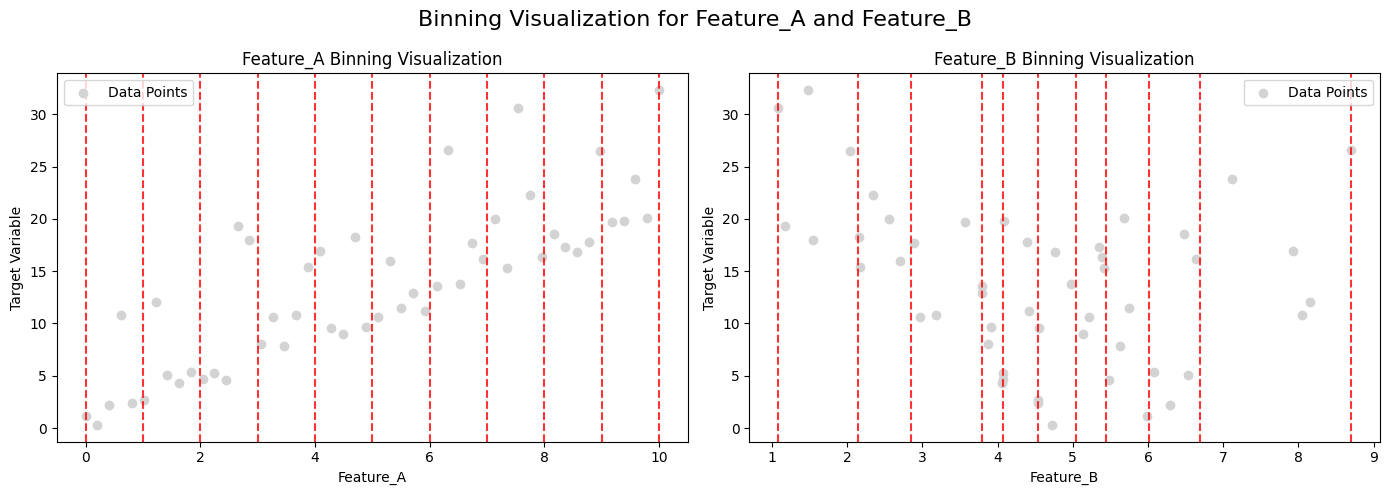

In [4]:
# Visualizing the binning process for Feature_A and Feature_B in two side-by-side plots

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Feature_A Binning Visualization
axs[0].scatter(X['Feature_A'], y, color='lightgray', label='Data Points')
for q in np.unique(np.quantile(X['Feature_A'], np.linspace(0, 1, 11))):
    axs[0].axvline(x=q, color='red', linestyle='--', alpha=0.8)
axs[0].set_title('Feature_A Binning Visualization')
axs[0].set_xlabel('Feature_A')
axs[0].set_ylabel('Target Variable')
axs[0].legend()

# Feature_B Binning Visualization
axs[1].scatter(X['Feature_B'], y, color='lightgray', label='Data Points')
for q in np.unique(np.quantile(X['Feature_B'], np.linspace(0, 1, 11))):
    axs[1].axvline(x=q, color='red', linestyle='--', alpha=0.8)
axs[1].set_title('Feature_B Binning Visualization')
axs[1].set_xlabel('Feature_B')
axs[1].set_ylabel('Target Variable')
axs[1].legend()

plt.suptitle('Binning Visualization for Feature_A and Feature_B', fontsize=16)
plt.tight_layout()
plt.show()

**Local Effects**: For each interval, we look at the data points that fall inside it. For these points, we calculate the difference in the model's prediction if we were to change the feature value from the left edge of the interval ($z_{k-1}$) to the right edge ($z_k$).
*   $Effect_{local} = Prediction(feature=z_k) - Prediction(feature=z_{k-1})$
*   This isolates the effect of the feature *within* that small range, keeping all other features constant.

To illustrate this, we can visualize the local effects within one of the bins, showing how predictions change as we move from the left edge to the right edge of the bin.

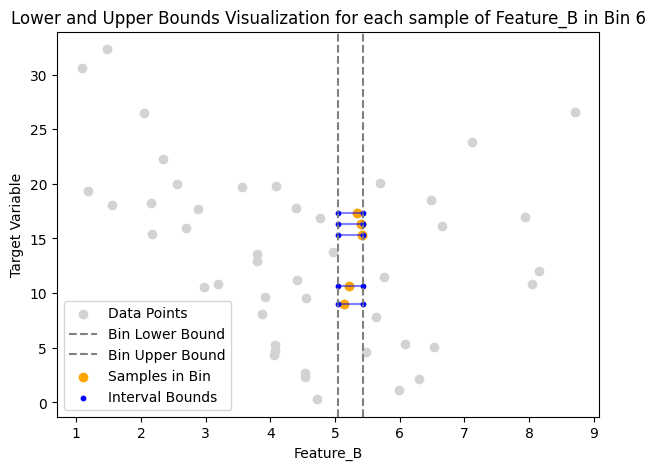

In [36]:
# Visualizing the local effects within bin n for a single feature

# Select feature to visualize
feature = 'Feature_B'
n_bins = 10
quantiles = np.linspace(0, 1, n_bins + 1)
grid = np.unique(np.quantile(X[feature], quantiles))

# Select a specific bin to highlight (e.g., the middle bin)
bin_idx = 6
z_lower = grid[bin_idx]
z_upper = grid[bin_idx+1]

# Get all samples in this bin
indices = X[(X[feature] >= z_lower) & (X[feature] < z_upper)].index
X_subset = X.loc[indices].copy()

# Display the highlighted bin and all data points, along with the bin boundaries
plt.figure(figsize=(7, 5))
plt.scatter(X[feature], y, color='lightgray', label='Data Points')
plt.axvline(x=z_lower, color='gray', linestyle='--', label='Bin Lower Bound')
plt.axvline(x=z_upper, color='gray', linestyle='--', label='Bin Upper Bound')
plt.scatter(X_subset[feature], y[indices], color='orange', label='Samples in Bin')

# Display the interval bounds for each sample in the bin
for idx in indices:
    plt.plot([z_lower, z_upper], [y[idx], y[idx]], color='blue', alpha=0.5)
    plt.scatter([z_lower, z_upper], [y[idx], y[idx]], color='blue', s=10, label='Interval Bounds' if idx == indices[0] else "")

plt.title(f'Lower and Upper Bounds Visualization for each sample of {feature} in Bin {bin_idx}')
plt.xlabel(feature)
plt.ylabel('Target Variable')
plt.legend()
plt.show()

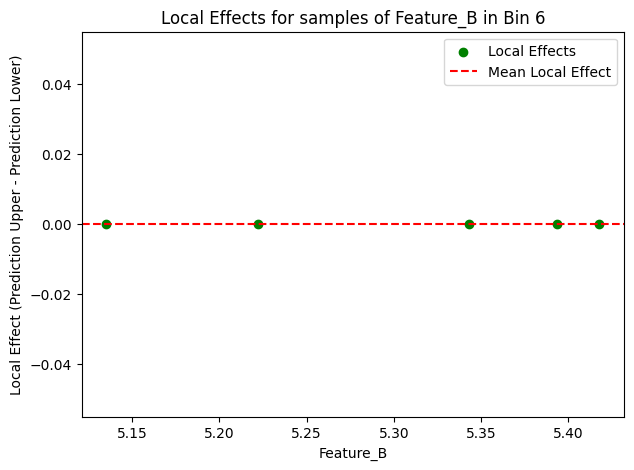

In [37]:
# Computing the local effects for bin n and visualizing them

# Predict for lower and upper bounds
X_lower = X_subset.copy()
X_lower[feature] = z_lower
X_upper = X_subset.copy()
X_upper[feature] = z_upper

preds_lower = model.predict(X_lower)
preds_upper = model.predict(X_upper)

# Calculate local effects
local_effects = preds_upper - preds_lower

# Visualize local effects
plt.figure(figsize=(7, 5))
plt.scatter(X_subset[feature], local_effects, color='green', label='Local Effects')
plt.axhline(y=np.mean(local_effects), color='red', linestyle='--', label='Mean Local Effect')
plt.title(f'Local Effects for samples of {feature} in Bin {bin_idx}')
plt.xlabel(feature)
plt.ylabel('Local Effect (Prediction Upper - Prediction Lower)')
plt.legend()
plt.show()

**Aggregation**: We average these local effects for each bin.

To illustrate this, we can create a bar plot showing the average local effects for each bin.

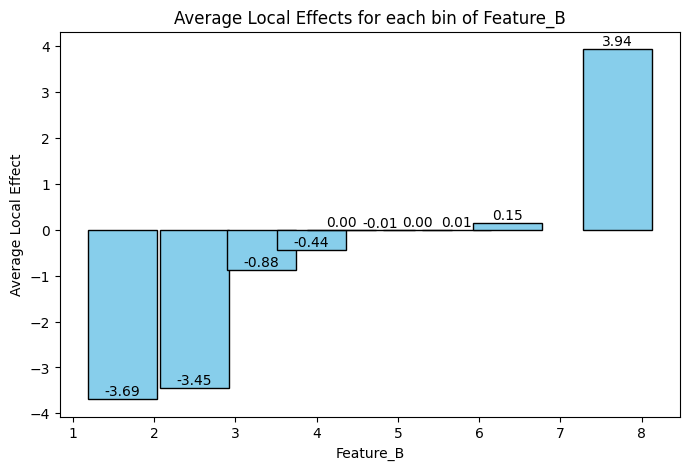

In [38]:
# Bar plot of average local effects for each bin of feature "feature"

# Calculate average local effects for each bin
avg_local_effects = []
for i in range(len(grid) - 1):
    z_lower = grid[i]
    z_upper = grid[i+1]
    
    # Find samples in this bin
    if i == len(grid) - 2:
        indices = X[(X[feature] >= z_lower) & (X[feature] <= z_upper)].index
    else:
        indices = X[(X[feature] >= z_lower) & (X[feature] < z_upper)].index
        
    if len(indices) == 0:
        avg_local_effects.append(0)
        continue
        
    X_subset = X.loc[indices].copy()
    
    X_lower = X_subset.copy()
    X_lower[feature] = z_lower
    
    X_upper = X_subset.copy()
    X_upper[feature] = z_upper
    
    preds_lower = model.predict(X_lower)
    preds_upper = model.predict(X_upper)
    
    local_effect = np.mean(preds_upper - preds_lower)
    avg_local_effects.append(local_effect)
    
# Create bar plot
plt.figure(figsize=(8, 5))
bin_centers = [(grid[i] + grid[i+1]) / 2 for i in range(len(grid) - 1)]
plt.bar(bin_centers, avg_local_effects, width=(grid[1]-grid[0])*0.8, color='skyblue', edgecolor='black')

# Add average local effect value for each bin on top of the bars
for i, effect in enumerate(avg_local_effects):
    plt.text(bin_centers[i], effect + 0.01, f'{effect:.2f}', ha='center', va='bottom')

plt.title(f'Average Local Effects for each bin of {feature}')
plt.xlabel(feature)
plt.ylabel('Average Local Effect')
plt.show()

**Accumulation**: We calculate the cumulative sum of these average effects to get the "Accumulated" profile.

To illustrate this, we can plot the cumulative sum of the average local effects across the bins.

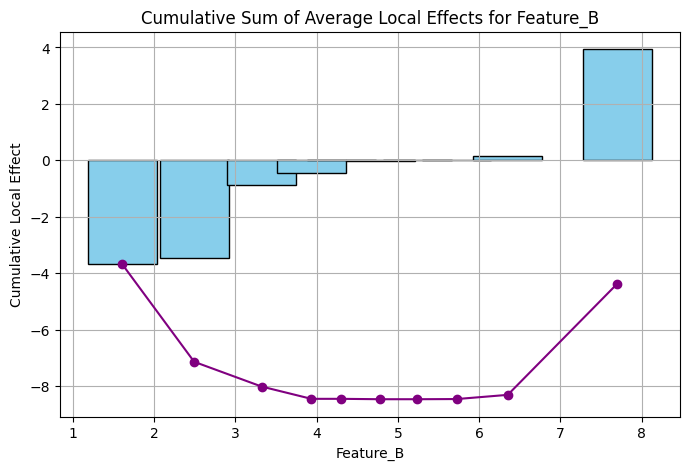

In [39]:
# Plotting the cumulative sum of the average local effects across the bins over the bar plot

cumulative_effects = np.cumsum(avg_local_effects)
plt.figure(figsize=(8, 5))
plt.bar(bin_centers, avg_local_effects, width=(grid[1]-grid[0])*0.8, color='skyblue', edgecolor='black')
plt.plot(bin_centers, cumulative_effects, marker='o', color='purple')
plt.title(f'Cumulative Sum of Average Local Effects for {feature}')
plt.xlabel(feature)
plt.ylabel('Cumulative Local Effect')
plt.grid()
plt.show()

**Centering**: To make the interpretation easier (showing deviation from the mean prediction), we center the ALE curve so that its average value is zero.

To illustrate this, we can adjust the ALE curve so that its mean value is zero, and plot the centered ALE values.

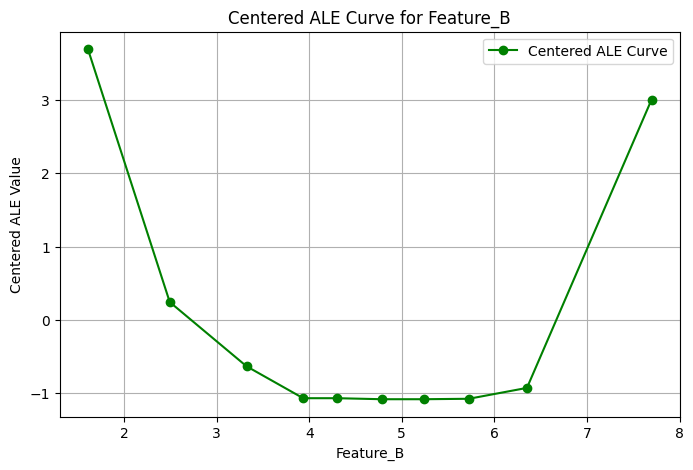

In [44]:
# Adjust the ALE curve so that its mean value is zero, and plot the centered ALE values

centered_cumulative_effects = cumulative_effects - np.mean(cumulative_effects)
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, centered_cumulative_effects, marker='o', color='green', label='Centered ALE Curve')
plt.title(f'Centered ALE Curve for {feature}')
plt.xlabel(feature)
plt.ylabel('Centered ALE Value')
plt.grid()
plt.legend()
plt.show()

## 5. Visualization

Now we visualize the effects of both features. We expect `Feature_A` to show a straight line (linear effect) and `Feature_B` to show a curve (quadratic effect).

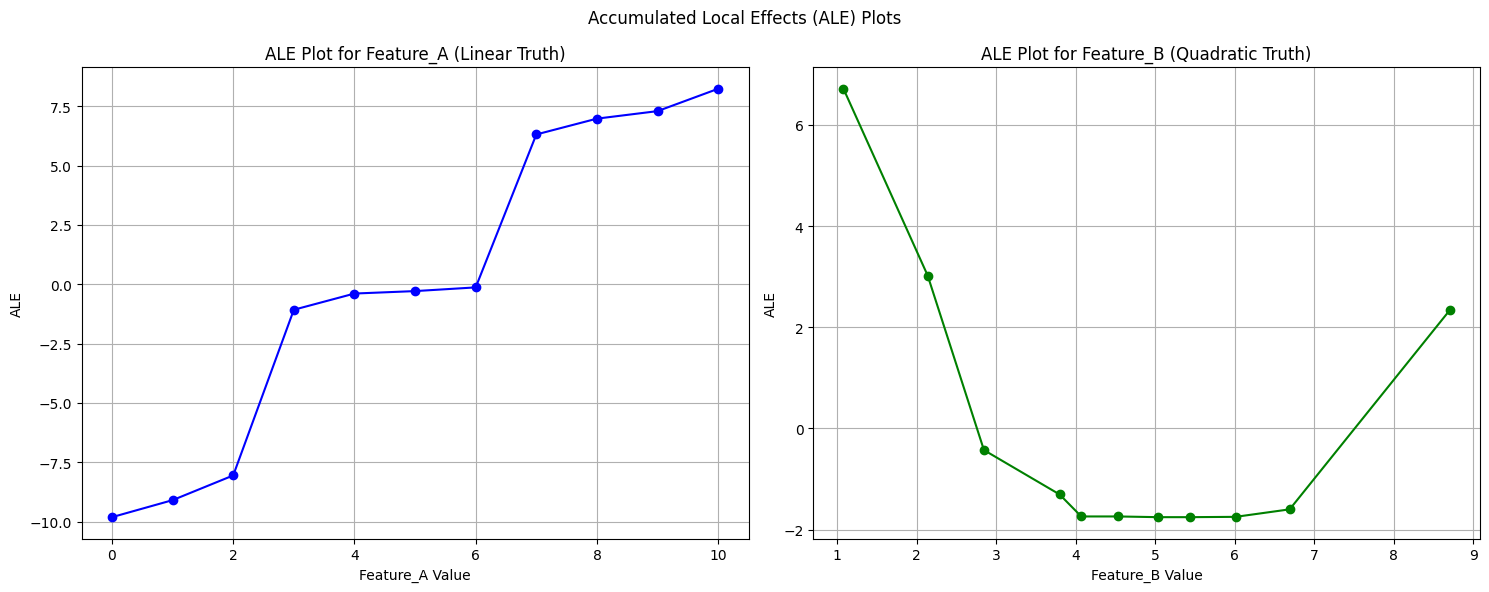

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Feature A
axes[0].plot(grid_a, ale_a, marker='o', color='blue')
axes[0].set_title('ALE Plot for Feature_A (Linear Truth)')
axes[0].set_xlabel('Feature_A Value')
axes[0].set_ylabel('ALE')
axes[0].grid(True)

# Plot Feature B
axes[1].plot(grid_b, ale_b, marker='o', color='green')
axes[1].set_title('ALE Plot for Feature_B (Quadratic Truth)')
axes[1].set_xlabel('Feature_B Value')
axes[1].set_ylabel('ALE')
axes[1].grid(True)

plt.suptitle('Accumulated Local Effects (ALE) Plots')
plt.tight_layout()
plt.show()

## 6. Analysis of Results

The plots above allow us to interpret the model's behavior:

1.  **Linear Effect (Feature_A)**:
    *   The ALE plot for `Feature_A` is a somewhat straight line with a constant positive slope. Note that the line is not perfectly straight due to the small sample size and noise in the data.
    *   This correctly identifies the linear relationship we engineered.
    *   The accumulated effects increase steadily, meaning higher values of A always lead to higher predictions.

2.  **Quadratic Effect (Feature_B)**:
    *   The ALE plot for `Feature_B` shows a parabolic (U-shaped) curve.
    *   The minimum is reached around x = 5, which matches our generation formula ($(B-5)^2$).
    *   This shows that the model has learned that values far from 5 (in either direction) increase the target value.

3.  **Robustness**:
    *   Even with only 50 samples and added noise, ALE provides a smooth and accurate representation of the underlying features.
    *   Though this is slightly more difficult to see with very few samples, the "binning" strategy seems to help average out the noise ($+ \epsilon$). We would expect this phenomenon to be more pronounced with larger datasets (or with less noise).